 **COVID-19 Early Case Trend Analysis & Recovery Insights**

IMPORT LIBRARIES

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
sns.set(style="whitegrid")

LOAD DATA

In [30]:
df = pd.read_csv('patient.csv')

In [31]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   id     sex  birth_year country               region group infection_reason  \
0   1  female      1984.0   China  filtered at airport   NaN   visit to Wuhan   
1   2    male      1964.0   Korea  filtered at airport   NaN   visit to Wuhan   
2   3    male      1966.0   Korea         capital area   NaN   visit to Wuhan   
3   4    male      1964.0   Korea         capital area   NaN   visit to Wuhan   
4   5    male      1987.0   Korea         capital area   NaN   visit to Wuhan   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0              1.0          NaN            45.0     2020-01-20    2020-02-06   
1              1.0          NaN            75.0     2020-01-24    2020-02-05   
2              1.0          NaN            16.0     2020-01-26    2020-02-12   
3              1.0          NaN            95.0     2020-01-27    2020-02-09   
4              1.0          NaN            31.0     2020-01-30           NaN   

  deceased_date     state  
0   

DATA CLEANING

In [32]:
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'], errors='coerce')
df['released_date'] = pd.to_datetime(df['released_date'], errors='coerce')

In [33]:
df['age'] = 2020 - df['birth_year']

In [34]:
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

HANDLE MISSING VALUES

In [35]:
df['contact_number'] = df['contact_number'].fillna(df['contact_number'].median())
df['infection_order'] = df['infection_order'].fillna(df['infection_order'].median())

In [36]:
df = df.dropna(subset=['recovery_days'])

VISUALIZATION

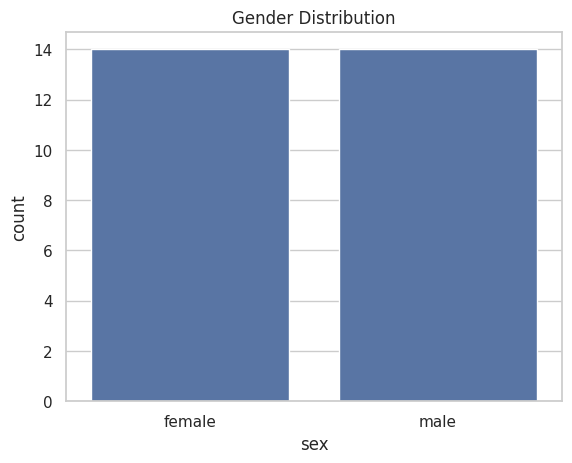

In [37]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

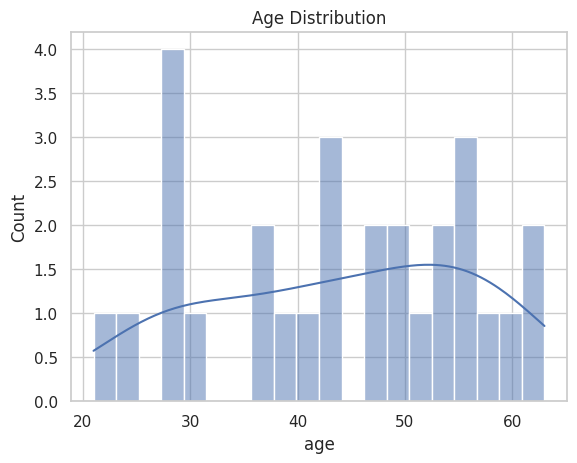

In [38]:
sns.histplot(df['age'].dropna(), bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

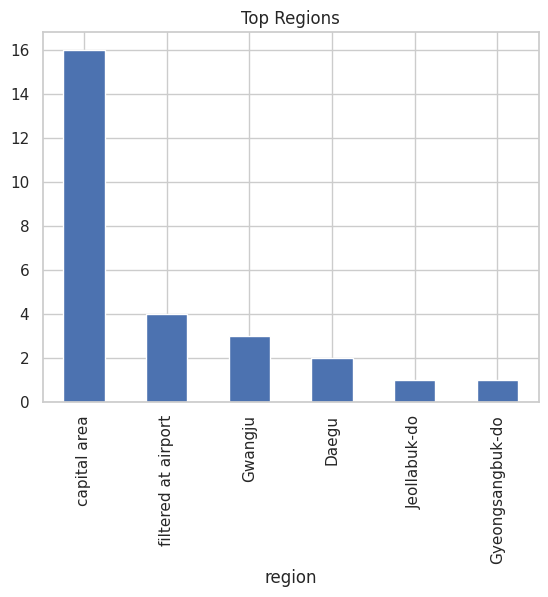

In [39]:

df['region'].value_counts().head(10).plot(kind='bar')
plt.title("Top Regions")
plt.show()

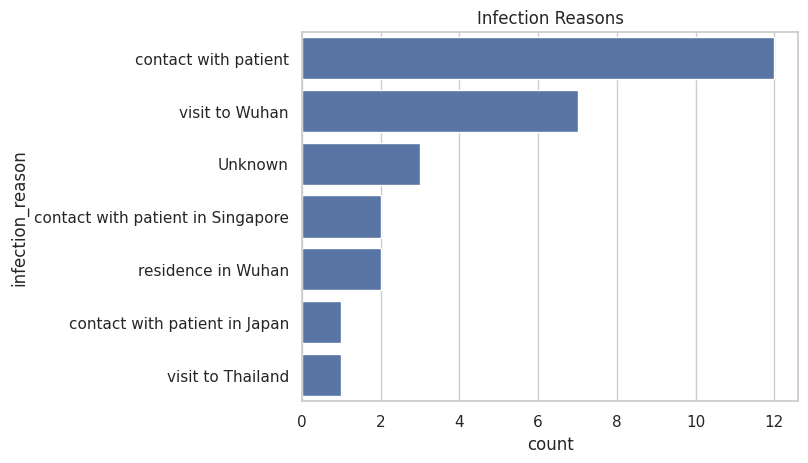

In [40]:
sns.countplot(y=df['infection_reason'].fillna("Unknown"),
              order=df['infection_reason'].fillna("Unknown").value_counts().index)
plt.title("Infection Reasons")
plt.show()

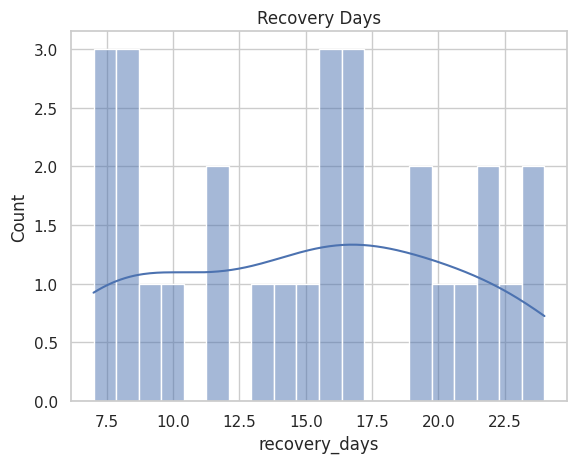

In [41]:
sns.histplot(df['recovery_days'], bins=20, kde=True)
plt.title("Recovery Days")
plt.show()

CORRELATION

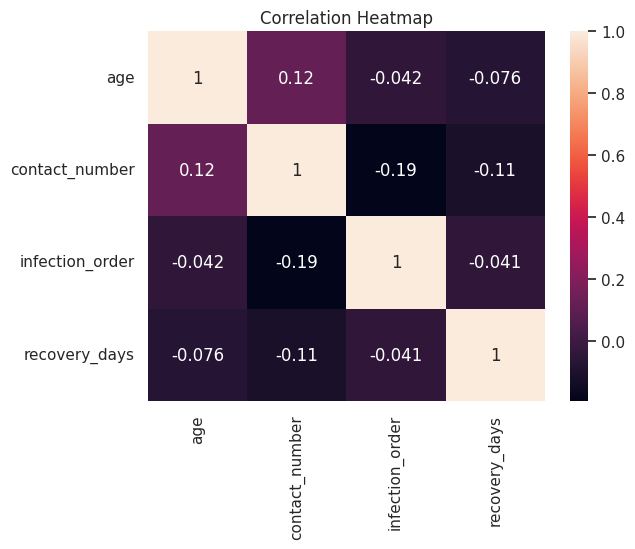

In [42]:



sns.heatmap(df[['age','contact_number','infection_order','recovery_days']].corr(),
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

State Analysis

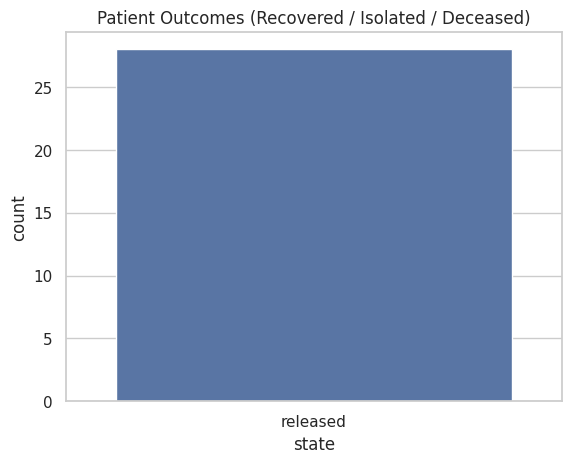

In [43]:
sns.countplot(x='state', data=df)
plt.title("Patient Outcomes (Recovered / Isolated / Deceased)")
plt.show()

Recovery Time by Gender

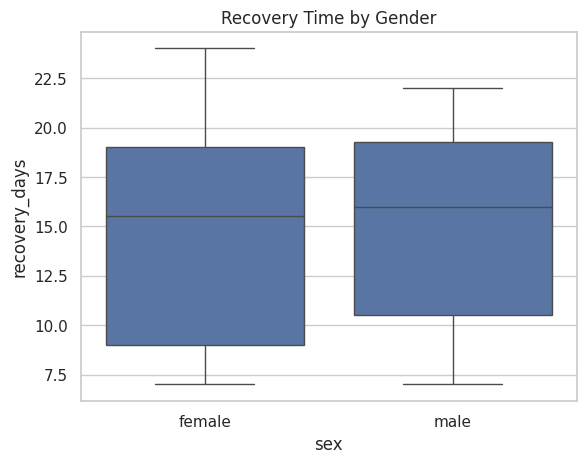

In [44]:
sns.boxplot(x='sex', y='recovery_days', data=df)
plt.title("Recovery Time by Gender")
plt.show()

Age Groups

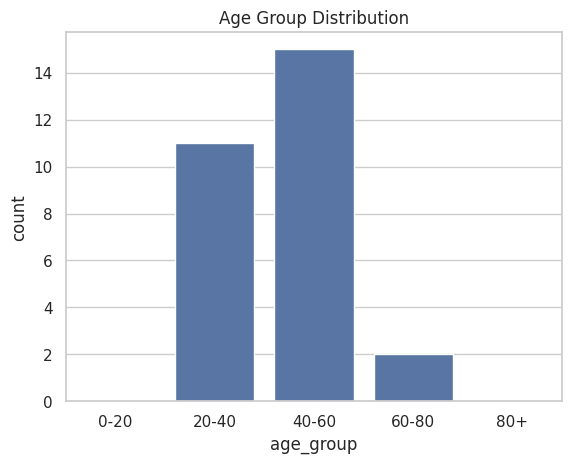

In [45]:
bins = [0,20,40,60,80,100]
labels = ['0-20','20-40','40-60','60-80','80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

sns.countplot(x='age_group', data=df)
plt.title("Age Group Distribution")
plt.show()

Monthly Trend Analysis

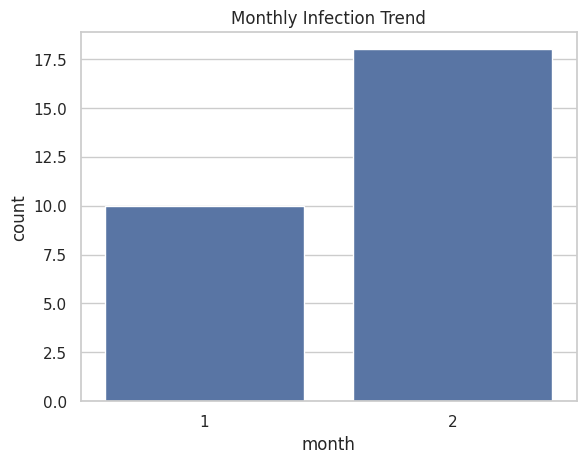

In [46]:
df['month'] = df['confirmed_date'].dt.month

sns.countplot(x='month', data=df)
plt.title("Monthly Infection Trend")
plt.show()

Survival Analysis

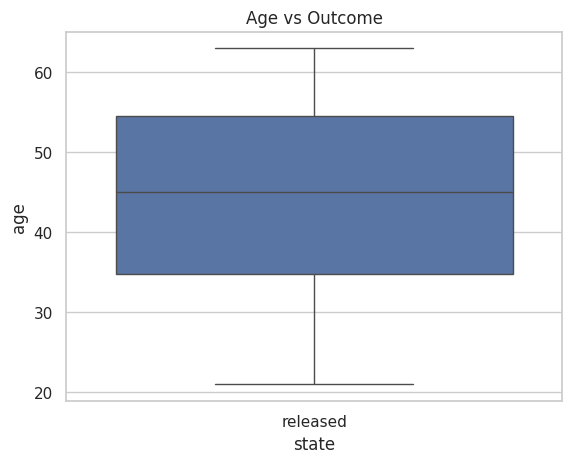

In [47]:
sns.boxplot(x='state', y='age', data=df)
plt.title("Age vs Outcome")
plt.show()

LINEAR REGRESSION

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [49]:
X = df[['age','contact_number','infection_order']]
y = df['recovery_days']


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)

In [53]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.1798187422280626


Feature Importance

In [54]:
print("Model Coefficients:")
print(pd.DataFrame(model.coef_, X.columns))

Model Coefficients:
                        0
age              0.026858
contact_number  -0.006612
infection_order -0.698023


In [55]:
df['state'].unique()

array(['released'], dtype=object)

In [56]:
df['state'].value_counts()

,count
state,
released,28
